In [1]:
#Imports 
import rasterio
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import f1_score, accuracy_score
from lightgbm import LGBMClassifier,early_stopping, log_evaluation
import numpy as np

## Importing data:

In [2]:
back = rasterio.open("/kaggle/input/competitions/geohab-mlwg-competition-2026/MBES/backscatter.tif")
bath = rasterio.open("/kaggle/input/competitions/geohab-mlwg-competition-2026/MBES/bathymetry.tif")
train_df = pd.read_csv('/kaggle/input/competitions/geohab-mlwg-competition-2026/train.csv')
test_df = pd.read_csv('/kaggle/input/competitions/geohab-mlwg-competition-2026/test.csv')

In [3]:
print('Train set: ', train_df.shape)
display(train_df.head())

print('Test set: ', test_df.shape)
display(test_df.head())

back_data = back.read(1)
print('Backscatter data: ',back_data.shape)
print(back_data[:5, :5])

bath_data = bath.read(1)
print('Bathymestry data: ', bath_data.shape)
print(bath_data[:5, :5])

Train set:  (6256, 3)


,class,x,y
0,NVB,453594.477237,5.679192e+06
1,FMAT,453561.906453,5.679109e+06
2,ALG,453744.452238,5.679033e+06
3,ALG,453863.445302,5.679038e+06
4,ALG,453964.611906,5.679017e+06


Test set:  (98, 3)


,ID,x,y
0,1,453702.166779,5.679044e+06
1,2,454126.252800,5.678999e+06
2,3,453957.881092,5.678942e+06
3,4,453798.917484,5.678955e+06
4,5,453520.953671,5.679124e+06


Backscatter data:  (4040, 4743)
[[-10000. -10000. -10000. -10000. -10000.]
 [-10000. -10000. -10000. -10000. -10000.]
 [-10000. -10000. -10000. -10000. -10000.]
 [-10000. -10000. -10000. -10000. -10000.]
 [-10000. -10000. -10000. -10000. -10000.]]
Bathymestry data:  (4040, 4743)
[[-10000. -10000. -10000. -10000. -10000.]
 [-10000. -10000. -10000. -10000. -10000.]
 [-10000. -10000. -10000. -10000. -10000.]
 [-10000. -10000. -10000. -10000. -10000.]
 [-10000. -10000. -10000. -10000. -10000.]]


## Extracting Features:

### Grid feature

In [4]:
def get_neighborhood_features(x, y):
    row, col = bath.index(x, y)
    
    features = []
    
    for dr in [-12, 0, 12]:
        for dc in [-12, 0, 12]:
            r = row + dr
            c = col + dc
            
            try:
                depth = bath_data[r, c]
                scatter = back_data[r, c]
            except:
                depth = 0
                scatter = 0
            
            features.append(depth)
            features.append(scatter)
    
    return features

In [5]:
features = train_df.apply(
    lambda r: get_neighborhood_features(r['x'], r['y']),
    axis=1
)

train_feature_cols = [f'f{i}' for i in range(len(features.iloc[0]))]

train_df[train_feature_cols] = pd.DataFrame(features.tolist(), index=train_df.index)

In [6]:
print(train_feature_cols)

['f0', 'f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9', 'f10', 'f11', 'f12', 'f13', 'f14', 'f15', 'f16', 'f17']


In [7]:
train_df.head()

,class,x,y,f0,f1,f2,f3,f4,f5,f6,...,f8,f9,f10,f11,f12,f13,f14,f15,f16,f17
0,NVB,453594.477237,5.679192e+06,-10000.000000,-10000.000000,-10000.000000,-10000.000000,-10000.000000,-10000.000000,-2.667833,...,-2.822883,-18.669088,-3.003832,-16.779381,-3.052902,-17.719353,-3.153770,-18.979156,-3.217835,-21.499985
1,FMAT,453561.906453,5.679109e+06,-5.861867,-24.649494,-5.705794,-19.609058,-5.636959,-19.928892,-5.808707,...,-5.668992,-20.558794,-5.697957,-22.129887,-6.120852,-20.558794,-5.797802,-21.189917,-6.232965,-21.189917
2,ALG,453744.452238,5.679033e+06,-9.233783,-24.339426,-8.520893,-24.019592,-8.426841,-24.339426,-9.579664,...,-9.288988,-23.389690,-9.054879,-23.709524,-9.672694,-27.169104,-10.006989,-21.189917,-10.029820,-23.709524
3,ALG,453863.445302,5.679038e+06,-6.856915,-24.339426,-6.731852,-24.339426,-6.698797,-25.599232,-7.546973,...,-7.263793,-21.189917,-6.937677,-22.449720,-8.047904,-19.609058,-7.883994,-18.039186,-7.642729,-21.819818
4,ALG,453964.611906,5.679017e+06,-8.769996,-24.339426,-7.727922,-20.238960,-7.976172,-24.649494,-9.685985,...,-9.784807,-22.449720,-8.631302,-28.749962,-10.117740,-25.599232,-10.628894,-27.169104,-10.871862,-27.488937


### Advanced feature engineering:

In [8]:
def get_advanced_features(x, y):
    row, col = bath.index(x, y)
    
    depths = []
    scatters = []
    
    for dr in [-10, 0, 10]:
        for dc in [-10, 0, 10]:
            r = row + dr
            c = col + dc
            
            if 0 <= r < bath_data.shape[0] and 0 <= c < bath_data.shape[1]:
                depths.append(bath_data[r, c])
                scatters.append(back_data[r, c])
            else:
                depths.append(0)
                scatters.append(0)
    
    return [
        np.mean(depths),
        np.std(depths),
        np.min(depths),
        np.max(depths),
        np.mean(scatters),
        np.std(scatters),
        np.min(scatters),
        np.max(scatters),
    ]

In [9]:
features = train_df.apply(
    lambda r: get_advanced_features(r['x'], r['y']),
    axis=1
)

adv_feature_cols = [
    'depth_mean', 'depth_std', 'depth_min', 'depth_max',
    'scatter_mean', 'scatter_std', 'scatter_min', 'scatter_max'
]

train_df[adv_feature_cols] = pd.DataFrame(features.tolist(), index=train_df.index)

In [10]:
print(adv_feature_cols)

['depth_mean', 'depth_std', 'depth_min', 'depth_max', 'scatter_mean', 'scatter_std', 'scatter_min', 'scatter_max']


## Model:

In [11]:
target = 'class'

X = train_df[train_feature_cols + adv_feature_cols]
y = train_df[target].map({'SGAM': 0, 'NVB': 1, 'SGZ': 2, 'ALG': 3, 'FMAT': 4})

#splitting the data into train/val splits
X_train , X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=24)

In [12]:
model = LGBMClassifier(random_state=42)
model.fit(X_train,y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001592 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4592
[LightGBM] [Info] Number of data points in the train set: 5004, number of used features: 26
[LightGBM] [Info] Start training from score -3.605338
[LightGBM] [Info] Start training from score -0.723170
[LightGBM] [Info] Start training from score -2.027269
[LightGBM] [Info] Start training from score -2.215374
[LightGBM] [Info] Start training from score -1.399167
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


LGBMClassifier(random_state=42)

In [13]:
val_preds = model.predict(X_val)
val_acc = accuracy_score(y_val, val_preds)
val_f1 = f1_score(y_val, val_preds, average='weighted')

print('Validation accuracy LGBM: ', val_acc)
print('Validation f1 LGBM: ', val_f1)

Validation accuracy LGBM:  0.952076677316294
Validation f1 LGBM:  0.9519350176264384


## Feature Importance

In [14]:
import lightgbm as lgbm
import matplotlib.pyplot as plt

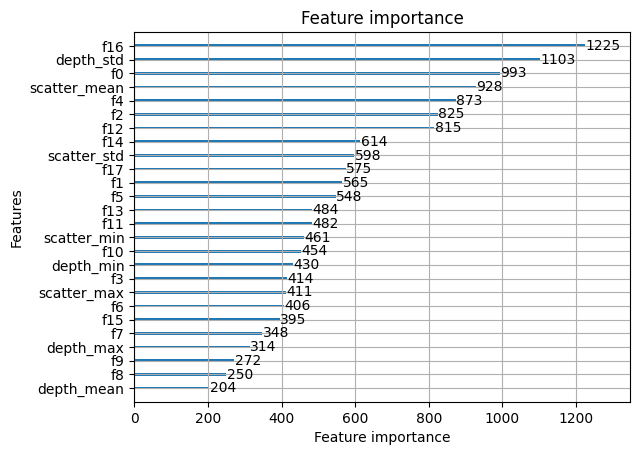

In [15]:
lgbm.plot_importance(model, max_num_features=30)
plt.show()

In [16]:
features = train_feature_cols + adv_feature_cols
importance = pd.Series(model.feature_importances_, index=features)
importance = importance.sort_values()

print(importance)

depth_mean       204
f8               250
f9               272
depth_max        314
f7               348
f15              395
f6               406
scatter_max      411
f3               414
depth_min        430
f10              454
scatter_min      461
f11              482
f13              484
f5               548
f1               565
f17              575
scatter_std      598
f14              614
f12              815
f2               825
f4               873
scatter_mean     928
f0               993
depth_std       1103
f16             1225
dtype: int32


## OOF preds

In [17]:
features = test_df.apply(
    lambda r: get_neighborhood_features(r['x'], r['y']),
    axis=1
)

test_feature_cols = [f'f{i}' for i in range(len(features.iloc[0]))]

test_df[test_feature_cols] = pd.DataFrame(features.tolist(), index=test_df.index)

In [18]:
features = test_df.apply(
    lambda r: get_advanced_features(r['x'], r['y']),
    axis=1
)

test_df[adv_feature_cols] = pd.DataFrame(features.tolist(), index=test_df.index)

In [19]:
X_test = test_df[test_feature_cols + adv_feature_cols]

## Seed averaging

In [20]:
seeds = [42, 52, 62, 72, 82]

In [21]:
# Hyperparameters found via Optuna
best_params = {
    "n_estimators": 2000,
    "learning_rate": 0.07918500203202344,
    "max_depth": 11,
    "num_leaves": 77,
    "subsample": 0.8055152296793877,
    "colsample_bytree": 0.7103689169741864,
    "reg_alpha": 0.014069050212386091,
    "reg_lambda": 0.7078441464734376,
    "min_child_samples": 9,
    "class_weight": "balanced",
    "random_state": 42,
    "device": "gpu",
    "n_jobs": -1,
    "verbose": -1,
}

all_test_probs = []
seed_scores = []

for seed in seeds:
    
    best_params["random_state"] = seed
    
    test_probs = np.zeros((len(X_test), len(np.unique(y))))
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    seed_fold_scores = []
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
        X_va, y_va = X.iloc[val_idx], y.iloc[val_idx]

        model = LGBMClassifier(**best_params)

        model.fit(
            X_tr, y_tr,
            eval_set=[(X_va, y_va)],
            callbacks=[early_stopping(50, verbose=False), log_evaluation(0)]
        )

        # CV score
        val_preds = model.predict(X_va)
        fold_f1 = f1_score(y_va, val_preds, average="weighted")
        seed_fold_scores.append(fold_f1)

        # test preds
        test_probs += model.predict_proba(X_test) / skf.n_splits

    seed_scores.append(np.mean(seed_fold_scores))
    all_test_probs.append(test_probs)

# weights
weights = np.array(seed_scores)
weights = weights / weights.sum()

# final ensemble
final_test_probs = np.zeros_like(all_test_probs[0])

for i in range(len(seeds)):
    final_test_probs += all_test_probs[i] * weights[i]

1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


In [22]:
print(seed_scores)

[np.float64(0.9469677546421214), np.float64(0.947952872295151), np.float64(0.9478187948918533), np.float64(0.948742594002065), np.float64(0.9477700683361368)]


In [23]:
print(weights)

[0.19981375 0.20002162 0.19999333 0.20018825 0.19998305]


In [24]:
classes = np.array(['SGAM', 'NVB', 'SGZ', 'ALG', 'FMAT'])  

final_preds = classes[np.argmax(final_test_probs, axis=1)]

submission = pd.DataFrame({
    'ID': test_df['ID'],
    target: final_preds
})

submission.to_csv('submission_seed_avg_weighted_ensemble.csv', index=False)

Well the scores are prettry much similar so this ensembling appraoch wont show any effect sadly T^T